### ReAct Agent Architecture

#### Aim
This is the intuition behind ReAct, a general agent architecture.

1. act - let the model call specific tools
2. observe - pass the tool output back to the model
3. reason - let the model reason about the tool output to decide what to do next (e.g., call another tool or just respond directly)

In [1]:
from langchain_community.tools import ArxivQueryRun,WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper,ArxivAPIWrapper

In [2]:
api_wrapper_arxiv=ArxivAPIWrapper(top_k_results=2,doc_content_chars_max=500)
arxiv=ArxivQueryRun(api_wrapper=api_wrapper_arxiv)
print(arxiv.name)

arxiv


In [3]:
arxiv.invoke("Attention iss all you need")

'Published: 2021-05-06\nTitle: Do You Even Need Attention? A Stack of Feed-Forward Layers Does Surprisingly Well on ImageNet\nAuthors: Luke Melas-Kyriazi\nSummary: The strong performance of vision transformers on image classification and other vision tasks is often attributed to the design of their multi-head attention layers. However, the extent to which attention is responsible for this strong performance remains unclear. In this short report, we ask: is the attention layer even necessary? Specifi'

In [4]:
api_wrapper_wiki=WikipediaAPIWrapper(top_k_results=1,doc_content_chars_max=500)
wiki=WikipediaQueryRun(api_wrapper=api_wrapper_wiki)
wiki.name

'wikipedia'

In [5]:
wiki.invoke("What is machine learning")

'Page: Machine learning\nSummary: Machine learning (ML) is a field of study in artificial intelligence concerned with the development and study of statistical algorithms that can learn from data and generalize to unseen data, and thus perform tasks without being explicitly programmed. Advances in the field of deep learning have allowed neural networks, a class of statistical algorithms, to surpass many previous machine learning approaches in performance.\nStatistics and mathematical optimisation me'

In [6]:
from dotenv import load_dotenv
load_dotenv()

import os

os.environ["TAVILY_API_KEY"]=os.getenv("TAVILY_API_KEY")
os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")
os.environ["LANGCHAIN_API_KEY"]=os.getenv("LANGCHAIN_API_KEY")
os.environ["LANGCHAIN_TRACING_V2"] = "true"
os.environ["LANGCHAIN_PROJECT"]="ReAct-agent"


In [7]:
### Custom Functions
def multiply(a: int, b: int) -> int:
    """Multiply a and b.

    Args:
        a: first int
        b: second int
    """
    return a * b

# This will be a tool
def add(a: int, b: int) -> int:
    """Adds a and b.

    Args:
        a: first int
        b: second int
    """
    return a + b

def divide(a: int, b: int) -> float:
    """Divide a and b.

    Args:
        a: first int
        b: second int
    """
    return a / b

tools=[arxiv,wiki,add,multiply,divide]

In [8]:
### Tavily Search Tool
from langchain_tavily import TavilySearch

tavily = TavilySearch()

In [9]:
tavily.invoke("Provide me the recent AI news for 6th May 2026")

{'query': 'Provide me the recent AI news for 6th May 2026',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://aitoolsrecap.com/Blog/ai-news-may-6-2026',
   'title': 'AI News May 6 2026: DeepSeek V4, Kimi K2.6 Undercut Claude by ...',
   'content': 'AI News May 6, 2026 — DeepSeek V4, Kimi K2.6 Undercuts Claude by 8x on Price. Your daily AI news digest for May 6, 2026 — model releases,',
   'score': 0.8815438,
   'raw_content': None},
  {'url': 'https://blog.mean.ceo/ai-advancements-news-may-2026/',
   'title': 'AI advancements News | May, 2026 (STARTUP EDITION)',
   'content': 'AI advancements news, May 2026: discover key trends in costs, competition, and regulation to help founders turn AI into real business',
   'score': 0.8029425,
   'raw_content': None},
  {'url': 'https://press.airstreet.com/p/state-of-ai-may-2026',
   'title': 'State of AI: May 2026 - Air Street Press',
   'content': "AISI says frontier cyber-offence is doubling every four

In [10]:
### Combine all the tools in the list

tools=[arxiv,wiki,tavily,add,divide,multiply]

In [11]:
## Initialize my LLM model

from langchain_groq import ChatGroq

llm=ChatGroq(model="openai/gpt-oss-120b")

llm_with_tools=llm.bind_tools(tools)

In [12]:
from pprint import pprint
from langchain_core.messages import AIMessage, HumanMessage, SystemMessage
llm_with_tools.invoke([HumanMessage(content=f"What is the recent AI News in brief")])

AIMessage(content='', additional_kwargs={'reasoning_content': 'The user asks: "What is the recent AI News in brief". They want a brief summary of recent AI news. Need up-to-date info. Use tavily_search to get recent AI news. Probably need top headlines from last week. Let\'s search.', 'tool_calls': [{'id': 'fc_d1e83dd6-e99e-48a0-a6cd-2cc10d27c7f9', 'function': {'arguments': '{"query":"latest AI news September 2026","search_depth":"fast","time_range":"week","topic":"news"}', 'name': 'tavily_search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 110, 'prompt_tokens': 539, 'total_tokens': 649, 'completion_time': 0.40611062, 'completion_tokens_details': {'reasoning_tokens': 52}, 'prompt_time': 1.214121647, 'prompt_tokens_details': {'cached_tokens': 512}, 'queue_time': 0.052095397, 'total_time': 1.620232267}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_8db49de948', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': No

In [13]:
llm_with_tools.invoke([HumanMessage(content=f"What is the recent AI News in brief")]).tool_calls

[{'name': 'tavily_search',
  'args': {'query': 'latest AI news September 2026',
   'search_depth': 'advanced',
   'time_range': 'week',
   'topic': 'news'},
  'id': 'fc_72a34483-8a43-47b2-b08b-4cdefa8d43f8',
  'type': 'tool_call'}]

In [14]:
## State Schema
from typing_extensions import TypedDict
from langchain_core.messages import AnyMessage
from typing import Annotated
from langgraph.graph.message import add_messages
class State(TypedDict):
    messages:Annotated[list[AnyMessage],add_messages]

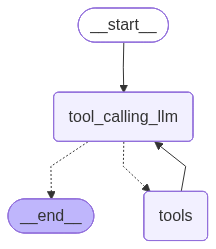

In [15]:
### Entire Chatbot With LangGraph
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

### Node definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tools.invoke(state["messages"])]}

# Build graph
builder = StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition,
)
builder.add_edge("tools","tool_calling_llm")


graph = builder.compile()

# View
display(Image(graph.get_graph().draw_mermaid_png()))


In [16]:
messages = graph.invoke({
    "messages": [
        SystemMessage(content="""
Use tools whenever available.
Prefer tools over internal reasoning.
For arithmetic, use math tools.
For external information, use search tools like Tavily and Wikipedia.
"""),

        HumanMessage(content="""
Provide me the recent AI news for 6th May 2026 in very short summary;
add 5 plus 5 and then multiply by 10
""")
    ]
})

for m in messages['messages']:
    m.pretty_print()

================================ System Message ================================


Use tools whenever available.
Prefer tools over internal reasoning.
For arithmetic, use math tools.
For external information, use search tools like Tavily and Wikipedia.

================================ Human Message =================================


Provide me the recent AI news for 6th May 2026 in very short summary;
add 5 plus 5 and then multiply by 10

================================== Ai Message ==================================
Tool Calls:
  add (fc_e58105e4-b917-45c5-8376-86865147cc77)
 Call ID: fc_e58105e4-b917-45c5-8376-86865147cc77
  Args:
    a: 5
    b: 5
================================= Tool Message =================================
Name: add

10
================================== Ai Message ==================================
Tool Calls:
  multiply (fc_7041e556-e83e-4258-ab2d-e2795abb4d53)
 Call ID: fc_7041e556-e83e-4258-ab2d-e2795abb4d53
  Args:
    a: 10
    b: 10
===================

In [18]:
messages=graph.invoke({"messages":HumanMessage(content="What is machine learning according to Wikipedia?")})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

What is machine learning according to Wikipedia?
================================== Ai Message ==================================
Tool Calls:
  wikipedia (fc_25664c41-3b30-4edc-a99d-9d692e0a4893)
 Call ID: fc_25664c41-3b30-4edc-a99d-9d692e0a4893
  Args:
    query: Machine learning
================================= Tool Message =================================
Name: wikipedia

Page: Machine learning
Summary: Machine learning (ML) is a field of study in artificial intelligence concerned with the development and study of statistical algorithms that can learn from data and generalize to unseen data, and thus perform tasks without being explicitly programmed. Advances in the field of deep learning have allowed neural networks, a class of statistical algorithms, to surpass many previous machine learning approaches in performance.
Statistics and mathematical optimisation me
================================== Ai